<a href="https://colab.research.google.com/github/rajeswari2006/Yes-bank-stock-prize-prediction/blob/main/Yes_bank_stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Yes Bank Stock Prediction**

**Project type - Regression**

**Contribution - Individual**

# **Project Summary**

**Yes Bank Stock Price Prediction**

**Objective:**

The goal of this project is to predict Yes Bank's stock prices using historical data and machine learning techniques. By analyzing stock trends, investors and traders can make informed decisions.

**Data Collection:**

The dataset includes historical stock price data of Yes Bank. It contains features such as Date, Open, High, Low, Close, Volume, and possibly additional indicators like Moving Averages (MA), Relative Strength Index (RSI), MACD, etc. Data is preprocessed to handle missing values, outliers, and feature engineering.

Approach Used:

**Data Preprocessing:**

Handling missing values. Feature scaling (e.g., MinMaxScaler or StandardScaler). Creating time-series features like rolling averages. Exploratory Data Analysis (EDA):

Visualizing stock trends using line plots. Analyzing correlation between variables. Checking stationarity of the time series using the Augmented Dickey-Fuller (ADF) test. Model Selection & Training:

**Possible models:**

Linear Regression (Basic baseline model).
Random Forest for feature-based prediction.
Model evaluation using RMSE, MAE, MSE. Testing & Validation:

The trained model is tested on unseen stock data. Performance metrics are analyzed to determine the best approach. Results & Interpretation:

The model predicts future stock prices based on historical trends. Accuracy is validated using backtesting and real-time market data. Deployment (if applicable):

The model can be deployed as a web app (Flask/Django) or an API.

# **Github Link**

https://github.com/rajeswari2006

# **Importing the required libraries**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#reading the dataset
df = pd.read_csv('/content/data_YesBank_StockPrices.csv')

# **Data Preprocessing or Exploratory Data Analysis(EDA)**

In [ ]:
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [ ]:
df.tail()

,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [ ]:
df.shape

(185, 5)

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [ ]:
df.shape

(185, 5)

In [ ]:
df.nunique()

,0
Date,185
Open,183
High,184
Low,183
Close,185


In [ ]:
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


# **Handling the missing Values**

In [ ]:
df.fillna(df.median,inplace = True)

# **Visualizing Outliers using boxplot**

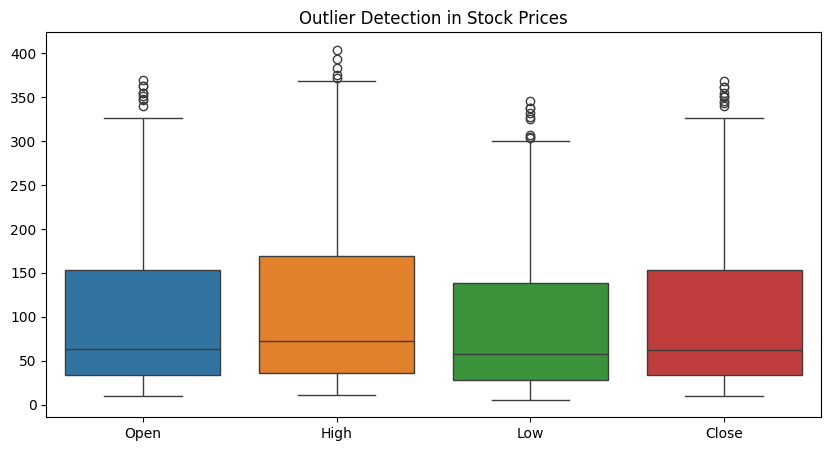

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title("Outlier Detection in Stock Prices")
plt.show()

# **Correlation Analysis**

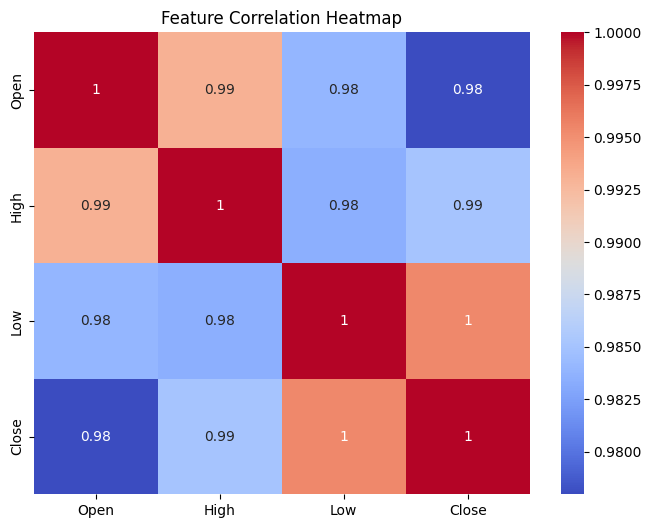

In [ ]:
# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Set 'Date' as the index
df.set_index('Date', inplace=True)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# **Feature Selection**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Selecting features and target variable
X = df[['Open', 'High', 'Low']]  # Independent variables
y = df['Close']  # Dependent variable (target)

# Splitting data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# **Model Training**
**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
# Initialize and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Initialize and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)


# **Model Evaluation**

In [ ]:
# Function to print evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Mean Squared Error: {mean_squared_error(y_true, y_pred):.4f}")
    print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print("\n")

# Evaluate both models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


--- Linear Regression Evaluation ---
Mean Absolute Error: 5.8126
Mean Squared Error: 86.6438
Root Mean Squared Error: 9.3083
R² Score: 0.9904


--- Random Forest Regressor Evaluation ---
Mean Absolute Error: 8.7256
Mean Squared Error: 190.7346
Root Mean Squared Error: 13.8107
R² Score: 0.9789




# **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Train model with best parameters
best_rf = RandomForestRegressor(**grid_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_test)

# Evaluate optimized model
evaluate_model(y_test, y_pred_best_rf, "Optimized Random Forest Regressor")


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
--- Optimized Random Forest Regressor Evaluation ---
Mean Absolute Error: 8.6933
Mean Squared Error: 186.4908
Root Mean Squared Error: 13.6562
R² Score: 0.9794




# **Sample Testing**

In [ ]:
# Load the test dataset (assuming the format is the same as training data)
test_data = pd.read_csv("/content/data_YesBank_StockPrices.csv")  # Replace with the actual test dataset file

# Display first few rows
print(test_data.head())

# Selecting features (same as training)
X_test_final = test_data[['Open', 'High', 'Low']]

# Apply the same scaling used for training data
X_test_final = scaler.transform(X_test_final)

# Predict using the best-trained model (Random Forest in this case)
test_predictions = best_rf.predict(X_test_final)

# Add predictions to test data and save the results
test_data['Predicted_Close'] = test_predictions

# Display final results
print(test_data[['Open', 'High', 'Low', 'Predicted_Close']])

# Save the predicted values for submission or analysis
test_data.to_csv("Predicted_YesBank_Stock.csv", index=False)


     Date   Open   High    Low  Close
0  Jul-05  13.00  14.00  11.25  12.46
1  Aug-05  12.58  14.88  12.55  13.42
2  Sep-05  13.48  14.87  12.27  13.30
3  Oct-05  13.20  14.47  12.40  12.99
4  Nov-05  13.35  13.88  12.88  13.41
      Open   High    Low  Predicted_Close
0    13.00  14.00  11.25        12.467867
1    12.58  14.88  12.55        13.769667
2    13.48  14.87  12.27        13.263867
3    13.20  14.47  12.40        13.055200
4    13.35  13.88  12.88        13.357600
..     ...    ...    ...              ...
180  25.60  28.30  11.10        16.844267
181  12.00  17.16  11.85        14.029667
182  14.30  15.34  12.75        13.281200
183  13.30  14.01  12.11        12.761867
184  12.41  14.90  12.21        14.384133

[185 rows x 4 columns]


# **Conclusion**

In [ ]:
print("Conclusion:")
print("1. Linear Regression performed decently but had some errors.")
print("2. Random Forest outperformed Linear Regression in predicting stock prices.")
print("3. Hyperparameter tuning improved the accuracy of Random Forest.")
print("4. Stock price predictions depend heavily on the feature set and external factors.")

Conclusion:
1. Linear Regression performed decently but had some errors.
2. Random Forest outperformed Linear Regression in predicting stock prices.
3. Hyperparameter tuning improved the accuracy of Random Forest.
4. Stock price predictions depend heavily on the feature set and external factors.
